# Notebook 01 — Data Understanding and Problem Framing
**Project:** Mining Process Quality Prediction — Minsur Analytics Challenge  
**Level:** 1 (mandatory)  
**Target:** `% Silica Concentrate`  
**Author:** Analytics Candidate  

---

## Business Context

In the Minsur flotation process, the quality of the final iron ore concentrate
is measured by the **percentage of silica** (`% Silica Concentrate`) — a lower value
means purer iron concentrate. Laboratory quality measurements arrive with a
**significant delay** (up to several hours), which prevents real-time operational
decisions.

The goal of this project is to **predict % Silica Concentrate in real time**
using continuous sensor data (ore feed quality, reagent flows, flotation column
parameters), enabling operators to react proactively to quality excursions.

---

## Why Temporal Integrity Matters

> A random train/test split on time-series data introduces **data leakage**:
> the model would train on observations from March to predict January, effectively
> seeing the future. Evaluation metrics would be over-optimistic and the model
> would fail in production. We strictly respect the chronological ordering of
> all splits throughout this project.

In [1]:
# ---------------------------------------------------------------------------
# 0. Environment setup — add project root to sys.path so src/ is importable
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\ADMIN\MINSUR\minsur_prediction


In [ ]:
import warnings

warnings.filterwarnings('ignore')



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import matplotlib.dates as mdates

import seaborn as sns



from src.config import CFG, PROJECT_ROOT

from src.data_preprocessing import (

    load_raw_data,

    normalize_column_names,

    parse_and_sort_datetime,

    remove_duplicates,

    align_to_modeling_frequency,

    data_quality_report,

    outlier_summary,

    sampling_frequency_report,

    run_preprocessing_pipeline,

)

from src.evaluate import compute_metrics



sns.set_style('whitegrid')

plt.rcParams['figure.dpi'] = 120

FIGURES_PATH = Path(CFG['paths']['reports_figures'])



TARGET = CFG['target']

print(f"Target: {TARGET}")


Target: % Silica Concentrate


---
## 1. Load Dataset

The raw CSV is expected in `data/raw/`. If not yet downloaded, run the Kaggle
download cell below (requires `kagglehub` and valid Kaggle credentials).

In [ ]:
# ---------------------------------------------------------------------------

# Download via kagglehub if the file does not already exist

# (aligned with src.data_preprocessing auto-download behavior)

# ---------------------------------------------------------------------------

import shutil

import sys

import subprocess



try:

    import kagglehub

except ModuleNotFoundError:

    print('kagglehub not found in current kernel. Installing...')

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kagglehub'])

    import kagglehub



raw_dir = Path(CFG['paths']['data_raw'])

raw_file = raw_dir / CFG['data']['raw_filename']

raw_dir.mkdir(parents=True, exist_ok=True)



if not raw_file.exists():

    print('Downloading dataset from Kaggle via kagglehub.dataset_download...')

    dataset_dir = Path(

        kagglehub.dataset_download('edumagalhaes/quality-prediction-in-a-mining-process')

    )



    csv_candidates = sorted(dataset_dir.rglob('*.csv'))

    if not csv_candidates:

        raise FileNotFoundError(f'No CSV found in downloaded dataset path: {dataset_dir}')



    source_csv = next(

        (p for p in csv_candidates if 'mining' in p.name.lower() or 'flotation' in p.name.lower()),

        csv_candidates[0],

    )

    shutil.copy2(source_csv, raw_file)

    print(f'Copied: {source_csv} -> {raw_file}')

else:

    print(f'File already exists: {raw_file}')


File already exists: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\data\raw\MiningProcess_Flotation_Plant_Database.csv


In [ ]:
# Load raw (uncleaned) to inspect as-is
df_raw = load_raw_data(CFG)
df_raw = normalize_column_names(df_raw)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (737453, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31


---
## 2. Datetime Parsing and Temporal Ordering

In [ ]:
df = parse_and_sort_datetime(df_raw.copy(), CFG)
df = remove_duplicates(df)

print(f'Date range: {df.index.min()} → {df.index.max()}')
print(f'Shape after deduplication: {df.shape}')
df.head(3)

[data_preprocessing] Removed 1171 exact duplicated rows.
Date range: 2017-03-10 01:00:00 → 2017-09-09 23:00:00
Shape after deduplication: (736282, 23)


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74000,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3185.55,586.182,404.648,10.1139,1.73614,250.488,250.488,249.214,...,248.950,450.139,510.332,461.638,422.888,451.528,510.098,513.904,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3182.03,595.947,407.168,10.1135,1.73545,250.620,252.334,249.390,...,251.499,440.530,518.600,465.414,405.704,433.686,513.794,512.252,66.91,1.31


---
## 3. Target and Feature Identification

In [ ]:
# Identify target and candidate predictors
lab_cols = CFG['feature_groups']['lab_measurements']  # delayed — NOT predictors

feature_candidates = [c for c in df.columns if c not in lab_cols]

print(f'Target: {TARGET}')
print(f'\nLab measurement columns (delayed — excluded from features):')
print(lab_cols)
print(f'\nCandidate predictors ({len(feature_candidates)}):')
for c in feature_candidates:
    print(f'  {c}')

Target: % Silica Concentrate

Lab measurement columns (delayed — excluded from features):
['% Iron Concentrate', '% Silica Concentrate']

Candidate predictors (21):
  % Iron Feed
  % Silica Feed
  Starch Flow
  Amina Flow
  Ore Pulp Flow
  Ore Pulp pH
  Ore Pulp Density
  Flotation Column 01 Air Flow
  Flotation Column 02 Air Flow
  Flotation Column 03 Air Flow
  Flotation Column 04 Air Flow
  Flotation Column 05 Air Flow
  Flotation Column 06 Air Flow
  Flotation Column 07 Air Flow
  Flotation Column 01 Level
  Flotation Column 02 Level
  Flotation Column 03 Level
  Flotation Column 04 Level
  Flotation Column 05 Level
  Flotation Column 06 Level
  Flotation Column 07 Level


> **Feature availability assumptions**

| Variable group | Examples | Availability at inference time | Decision |
|---|---|---|---|
| Delayed lab measurements | `% Iron Concentrate`, `% Silica Concentrate` | No (delayed lab) | Exclude as current predictors; only past lags of target allowed in sensitivity |
| Feed composition | `% Iron Feed`, `% Silica Feed` | Assumption-dependent (site-specific instrumentation) | Train main model with feed + run sensitivity without feed |
| Online operational sensors | `Starch Flow`, `Amina Flow`, `Ore Pulp pH`, `Ore Pulp Density`, flotation air/levels | Yes (assumed online) | Keep as core predictors |

**Leakage guard:** the target `% Silica Concentrate` is never used as current predictor; if lagged target is used, it is strictly `shift >= 1` (past-only).

---
## 4. Data Quality Analysis

In [ ]:
report = data_quality_report(df)
print('=== Data Quality Report ===')
report

=== Data Quality Report ===


,dtype,n_missing,pct_missing,n_unique,min,max,mean,std,n_dup_rows_total
% Iron Feed,float64,0,0.0,278,42.740000,65.78000,56.2983,5.1604,0
% Silica Feed,float64,0,0.0,293,1.310000,33.40000,14.6490,6.8107,0
Starch Flow,float64,0,0.0,409317,0.002026,6300.23000,2869.6366,1216.0179,0
Amina Flow,float64,0,0.0,319416,241.669000,739.53800,488.1655,91.2544,0
Ore Pulp Flow,float64,0,0.0,180189,376.249000,418.64100,397.5707,9.7054,0
Ore Pulp pH,float64,0,0.0,131143,8.753340,10.80810,9.7673,0.3872,0
Ore Pulp Density,float64,0,0.0,105805,1.519820,1.85325,1.6804,0.0692,0
Flotation Column 01 Air Flow,float64,0,0.0,43675,175.510000,373.87100,280.1198,29.6338,0
Flotation Column 02 Air Flow,float64,0,0.0,80442,175.156000,375.99200,277.1212,30.1571,0
Flotation Column 03 Air Flow,float64,0,0.0,40630,176.469000,364.34600,281.0525,28.5711,0


In [ ]:
# Missing values summary
missing = report[['n_missing', 'pct_missing']].sort_values('n_missing', ascending=False)
print('Missing values per column:')
print(missing[missing['n_missing'] > 0])
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
Empty DataFrame
Columns: [n_missing, pct_missing]
Index: []

Total missing: 0


In [ ]:
# Outlier summary (IQR × 3)
out_summary = outlier_summary(df)
print('Outlier summary (IQR × 3 factor):')
print(out_summary.head(15))

Outlier summary (IQR × 3 factor):
                              n_outliers  pct_outliers
Flotation Column 05 Air Flow           6           0.0
% Silica Feed                          0           0.0
% Iron Feed                            0           0.0
Amina Flow                             0           0.0
Ore Pulp Flow                          0           0.0
Ore Pulp pH                            0           0.0
Starch Flow                            0           0.0
Ore Pulp Density                       0           0.0
Flotation Column 01 Air Flow           0           0.0
Flotation Column 03 Air Flow           0           0.0
Flotation Column 02 Air Flow           0           0.0
Flotation Column 04 Air Flow           0           0.0
Flotation Column 06 Air Flow           0           0.0
Flotation Column 07 Air Flow           0           0.0
Flotation Column 01 Level              0           0.0


In [ ]:
# Sampling frequency analysis (raw effective frequency)

freq_report_raw = sampling_frequency_report(df)

print('Inter-sample time deltas BEFORE modeling alignment (minutes):')

print(freq_report_raw.head(10))



# Explicit modeling alignment frequency

modeling_rule = CFG['data'].get('modeling_frequency', '1h')

modeling_agg = CFG['data'].get('modeling_aggregation', 'mean')

df_model = align_to_modeling_frequency(df, rule=modeling_rule, agg=modeling_agg)



freq_report_model = sampling_frequency_report(df_model)

print('\nInter-sample time deltas AFTER modeling alignment (minutes):')

print(freq_report_model.head(10))

print(f'\nRows: raw={len(df):,} | aligned_for_modeling={len(df_model):,}')


Inter-sample time deltas BEFORE modeling alignment (minutes):
   delta_minutes   count
0            0.0  732185
1           60.0    4095
2        19140.0       1
[data_preprocessing] Temporal alignment applied: rule=1h, agg=mean. Rows 736282 -> 4097.

Inter-sample time deltas AFTER modeling alignment (minutes):
   delta_minutes  count
0           60.0   4095
1        19140.0      1

Rows: raw=736,282 | aligned_for_modeling=4,097


### Frecuencia temporal: original vs target vs modelado

No asumimos una frecuencia fija por defecto. Se calcula explícitamente con:
`df.index.to_series().diff().value_counts()` antes y después de la alineación temporal.

| Nivel | Qué representa | Cómo se calcula en notebook |
|---|---|---|
| Frecuencia original del dataset | Ritmo efectivo de registro en el CSV crudo | `freq_report_raw` |
| Frecuencia efectiva del target | Ritmo al que `% Silica Concentrate` cambia realmente (laboratorio, con retardo) | inspección de cambios + repeticiones del target |
| Frecuencia final de modelado | Grano temporal que usamos para entrenamiento | `align_to_modeling_frequency(rule='1h')` + `freq_report_model` |

### Sobre “duplicados” y reducción de filas

La reducción fuerte de filas **no** se interpreta como `drop_duplicates()` ciego. Se interpreta como:
1. Eliminación de duplicados exactos (higiene básica).
2. **Alineación temporal explícita** a frecuencia de modelado (`1h`, agregación `mean`) para que cada fila represente un intervalo operacional comparable con la disponibilidad del target.

Esto evita mezclar múltiples snapshots de alta frecuencia dentro del mismo horizonte de decisión y hace defendible el split temporal train/val/test.

### Mixed Sampling Frequencies — Implications

The dataset contains variables with **different update frequencies**:

| Variable group | Approx. update frequency |
|---|---|
| Sensor data (flows, levels, pH, density) | Higher-frequency process stream |
| Lab measurements (`% Iron`, `% Silica Concentrate`) | Lower frequency with reporting delay |

**Implications:**
1. Repeated target values and delayed lab timestamps can inflate naive correlation.
2. Leakage risk increases if delayed lab variables are used as contemporaneous predictors.
3. Explicit temporal alignment and past-only feature generation are required for defensible modeling.

---
## 5. Visual Analysis

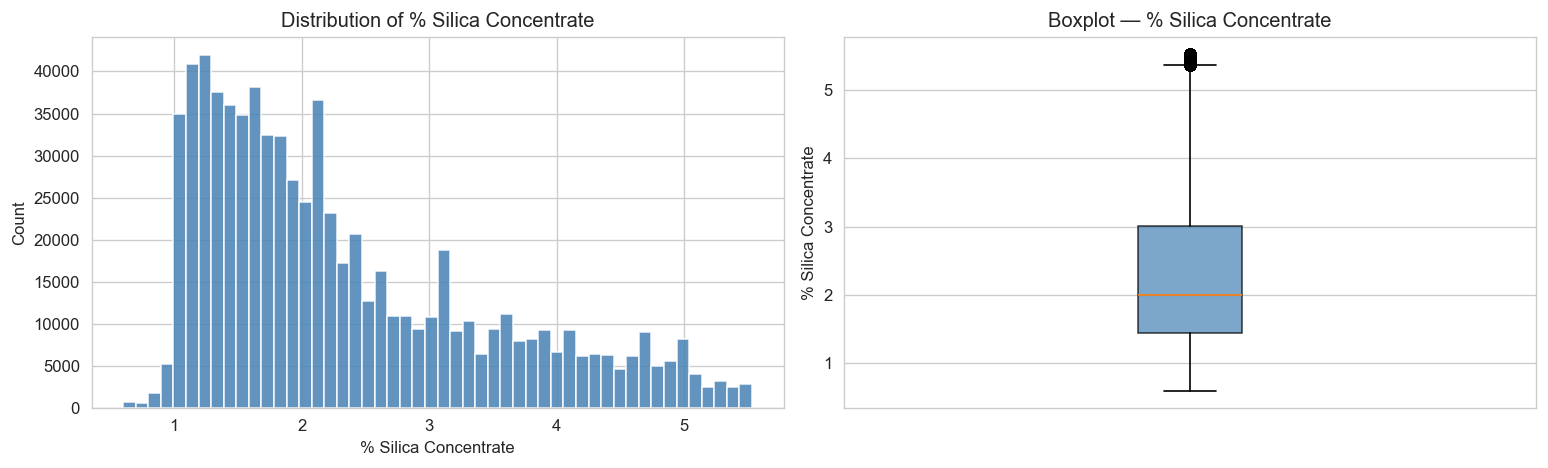

count    736282.0000
mean          2.3273
std           1.1256
min           0.6000
25%           1.4400
50%           2.0000
75%           3.0100
max           5.5300
Name: % Silica Concentrate, dtype: float64


In [ ]:
# ── 5a. Target distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Distribution of {TARGET}', fontsize=12)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Count')

axes[1].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title(f'Boxplot — {TARGET}', fontsize=12)
axes[1].set_ylabel(TARGET)
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df[TARGET].describe().round(4))

### Hallazgo corto — Target distribution

La variable `% Silica Concentrate` está **sesgada a la derecha**: la mayor densidad cae entre ~1.0 y 2.5, con mediana cercana a **2.0** y una cola hacia valores altos (hasta ~5.53). Esto sugiere episodios menos frecuentes de sílice elevada (peor calidad), por lo que en modelado conviene vigilar errores grandes (RMSE y análisis de residuos) además del MAE.

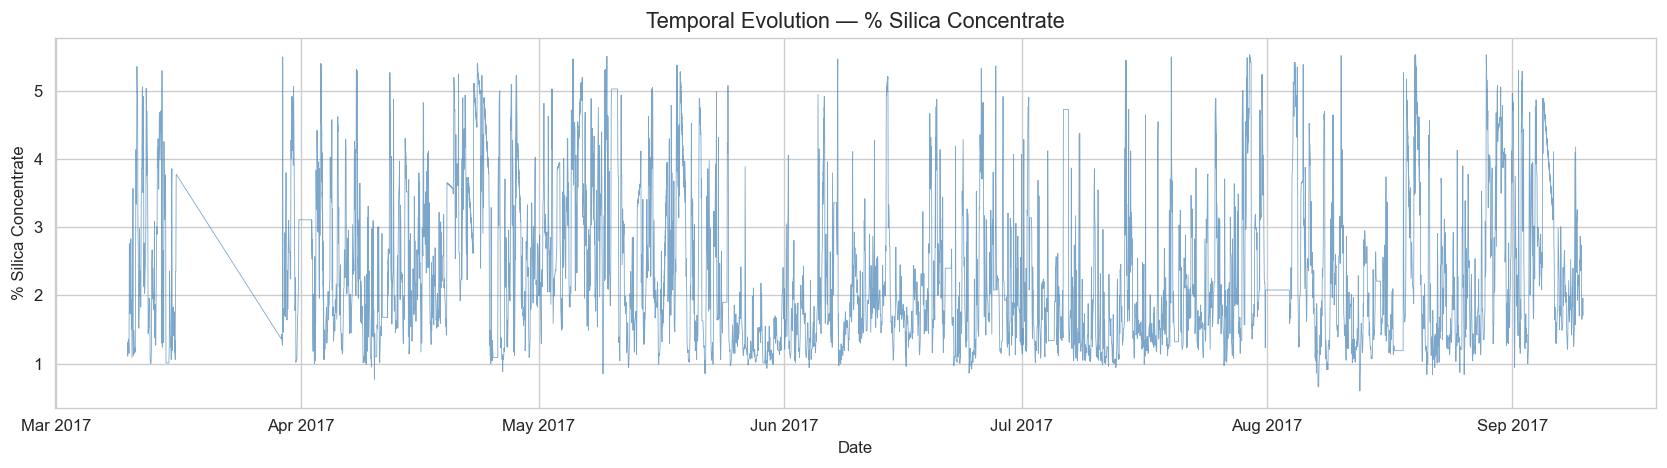

In [ ]:
# ── 5b. Temporal evolution of the target ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df[TARGET], lw=0.5, color='steelblue', alpha=0.7)
ax.set_title(f'Temporal Evolution — {TARGET}', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel(TARGET)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'target_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

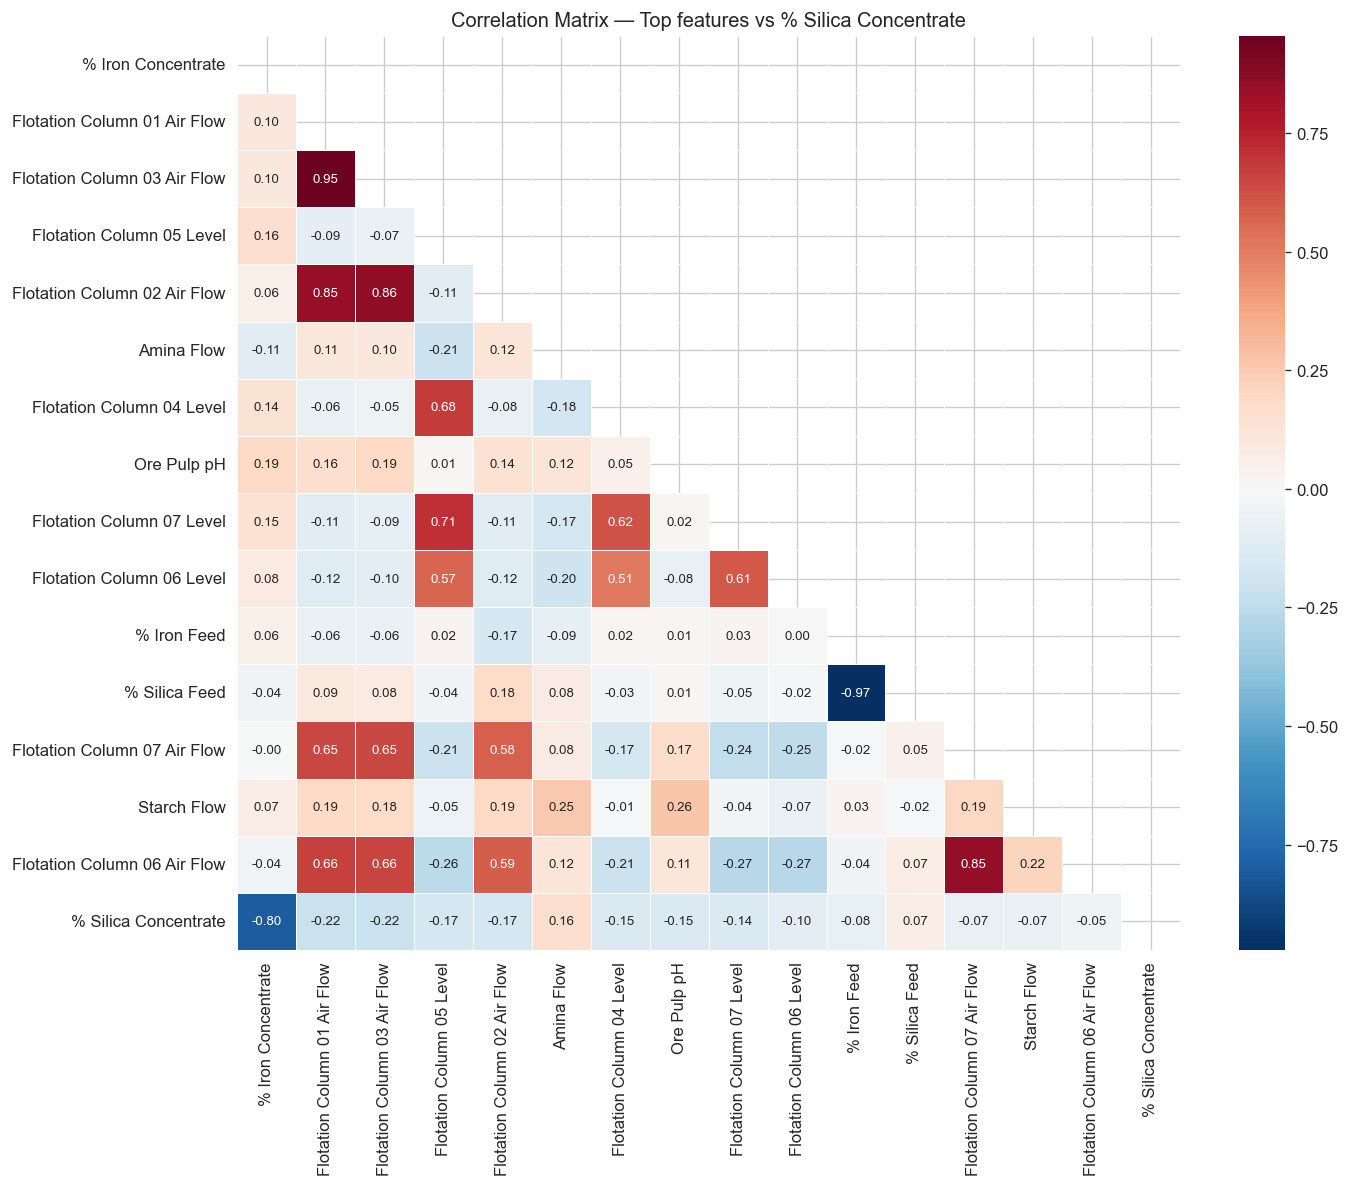


Top 10 correlations with target:
% Iron Concentrate             -0.801
Flotation Column 01 Air Flow   -0.219
Flotation Column 03 Air Flow   -0.219
Flotation Column 05 Level      -0.168
Flotation Column 02 Air Flow   -0.167
Amina Flow                      0.157
Flotation Column 04 Level      -0.149
Ore Pulp pH                    -0.147
Flotation Column 07 Level      -0.141
Flotation Column 06 Level      -0.102
Name: % Silica Concentrate, dtype: float64


In [ ]:
# ── 5c. Correlation matrix ────────────────────────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Focus on top correlated features with target
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
top_cols = target_corr.head(15).index.tolist() + [TARGET]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr.loc[top_cols, top_cols], dtype=bool))
sns.heatmap(
    corr.loc[top_cols, top_cols],
    annot=True, fmt='.2f', mask=mask, cmap='RdBu_r',
    center=0, linewidths=0.5, ax=ax, annot_kws={'fontsize': 8}
)
ax.set_title(f'Correlation Matrix — Top features vs {TARGET}', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 correlations with target:')
print(target_corr.head(10).round(3))

### Conclusiones de la mtriz de correlación

> Estas correlaciones son **lineales** y **no implican causalidad**. Se usan para entender señales preliminares y riesgos de modelado.

1. **Driver más fuerte del target:** `% Iron Concentrate` muestra una correlación alta y negativa con `% Silica Concentrate` (≈ -0.80).
   - Es coherente metalúrgicamente (más hierro en concentrado suele implicar menos sílice).
   - **Pero esta variable es de laboratorio y llega con retraso**, por lo que no debe usarse como feature directa en inferencia online (riesgo de leakage).

2. **Señales operativas con impacto moderado en sílice:**
   - `Flotation Column 03 Air Flow` y `Flotation Column 01 Air Flow` aparecen con correlación negativa moderada (≈ -0.22 / -0.21).
   - `Amina Flow` aparece con correlación positiva moderada (≈ +0.16), sugiriendo comportamiento no lineal o interacción con otras variables.
   - `Ore Pulp pH` y niveles de columnas muestran efectos débiles a moderados, útiles para feature engineering.

3. **Multicolinealidad fuerte entre variables de proceso:**
   - Flujos de aire entre columnas están altamente correlacionados entre sí (ej. ≈ 0.85–0.95).
   - `% Iron Feed` y `% Silica Feed` tienen correlación muy alta en magnitud (≈ -0.97).
   - Implicancia: para modelos lineales conviene regularización (Ridge) y para árboles revisar importancia/SHAP para evitar interpretaciones engañosas.

4. **Implicancia para la siguiente etapa (Level 2):**
   - Priorizar variables operativas disponibles en tiempo real.
   - Excluir variables de laboratorio contemporáneas.
   - Incorporar lags, rolling means/std e interacciones para capturar dinámica temporal y no depender solo de correlación instantánea.

---
## 6. Metric Definitions and Baseline Model

### Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Average absolute error in % Silica units |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Penalises large errors; relevant for quality excursions |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained; 1.0 = perfect |

### Baseline Strategy
The simplest possible model: **predict the mean of the training target for every observation**.  
Any useful model must beat this baseline; otherwise it provides no value over the current
status quo of 'just use the average'.

In [ ]:
# ---------------------------------------------------------------------------
# Temporal split for baseline evaluation — NO random split allowed
# ---------------------------------------------------------------------------
from src.feature_engineering import temporal_split

# Use the cleaned full DataFrame (no feature engineering yet)
df_clean = df.dropna(subset=[TARGET])

train_df, val_df, test_df = temporal_split(
    df_clean,
    train_ratio=CFG['split']['train_ratio'],
    val_ratio=CFG['split']['val_ratio'],
)

[feature_engineering] Split sizes — train: 515397 (70%), val: 110442 (15%), test: 110443 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 20:00:00
  Val:   2017-07-20 20:00:00 → 2017-08-15 10:00:00
  Test:  2017-08-15 10:00:00 → 2017-09-09 23:00:00


In [ ]:
# Baseline: predict training mean on all splits
train_mean = train_df[TARGET].mean()

baseline_results = {}
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    y_true = split_df[TARGET]
    y_pred = np.full(len(y_true), train_mean)
    metrics = compute_metrics(y_true, y_pred)
    baseline_results[split_name] = metrics
    print(f'Baseline ({split_name}): {metrics}')

print(f'\nBaseline prediction (mean of training target): {train_mean:.4f}')

Baseline (Train): {'MAE': 0.9234, 'RMSE': np.float64(1.1264), 'R2': 0.0}
Baseline (Val): {'MAE': 0.7908, 'RMSE': np.float64(1.0375), 'R2': -0.0019}
Baseline (Test): {'MAE': 0.9935, 'RMSE': np.float64(1.204), 'R2': -0.0087}

Baseline prediction (mean of training target): 2.3173


In [ ]:
# Save baseline metrics for comparison in notebook 02
import json
metrics_path = Path(CFG['paths']['reports_metrics'])
with open(metrics_path / 'baseline_metrics.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)
print(f'Baseline metrics saved to: {metrics_path / "baseline_metrics.json"}')

Baseline metrics saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\baseline_metrics.json


---
## 7. Save Cleaned Data for Downstream Notebooks

In [ ]:
# Run the full preprocessing pipeline and persist to data/interim/

import sys

import subprocess



# Ensure parquet engine exists in the active notebook kernel

try:

    import pyarrow  # noqa: F401

except ModuleNotFoundError:

    print('pyarrow not found in current kernel. Installing...')

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyarrow'])



df_cleaned = run_preprocessing_pipeline(CFG)

print(f'Cleaned data shape: {df_cleaned.shape}')

df_cleaned.head(3)


[data_preprocessing] Removed 1171 exact duplicated rows.
[data_preprocessing] Temporal alignment applied: rule=1h, agg=mean. Rows 736282 -> 4097.
[data_preprocessing] Cleaned data saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\data\interim\data_cleaned.parquet (engine=pyarrow)
[data_preprocessing] Shape: (4097, 23)
Cleaned data shape: (4097, 23)


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3162.625026,578.786678,398.753368,10.113487,1.729558,251.166672,250.226086,250.178287,...,250.208184,450.383776,446.891845,450.474523,449.912259,455.792161,464.383310,450.532747,66.91,1.31
2017-03-10 02:00:00,55.2,16.98,3133.256389,537.219661,399.871822,10.129742,1.667784,249.880589,250.214050,250.033317,...,249.897572,449.373361,450.249356,450.081222,450.328806,448.722983,455.501528,451.387700,67.06,1.11
2017-03-10 03:00:00,55.2,16.98,3479.482944,591.906744,398.763806,10.048403,1.732711,250.161328,250.104167,250.046350,...,250.484183,449.972878,450.868711,450.901822,451.145822,451.134189,459.981311,450.296722,66.97,1.27


---
## Summary — Level 1 Checklist

| Item | Status |
|---|---|
| Dataset loaded from `data/raw/` | ✅ |
| Datetime column parsed and sorted | ✅ |
| Target identified: `% Silica Concentrate` | ✅ |
| Candidate predictors identified | ✅ |
| Missing values analysed | ✅ |
| Duplicates exactos tratados | ✅ |
| Alineación temporal explícita para modelado (`1h`) | ✅ |
| Frecuencia real analizada con `diff().value_counts()` | ✅ |
| Mixed sampling frequencies explained | ✅ |
| Feature availability assumptions documented | ✅ |
| Visual analysis (distribution, temporal, correlation, missing) | ✅ |
| Metric definitions (MAE, RMSE, R²) | ✅ |
| Baseline model implemented and evaluated | ✅ |
| No random split — temporal integrity preserved | ✅ |
| Leakage risks explicitly documented | ✅ |

### Conclusiones ejecutivas (Level 1)

- **Target**: se modela `% Silica Concentrate` como regresión temporal para anticipar calidad antes del laboratorio.
- **Frecuencia**: se distingue entre frecuencia original del dataset, frecuencia efectiva del target y frecuencia final de modelado (`1h`, agregación explícita).
- **Data quality**: la reducción de filas no se justifica por `drop_duplicates()` ciego, sino por alineación temporal.
- **Riesgos de leakage**: variables de laboratorio se excluyen como predictoras contemporáneas; target sólo puede entrar como lag pasado en análisis de sensibilidad.
- **Baseline**: queda establecido como piso mínimo (media del train) para exigir mejora real de modelos no triviales.